In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns  # a useful plotting library on top of matplotlib
from tqdm.auto import tqdm # a nice progress bar

We want to generate a dataset of 1D data from a mixture of two Gaussians with mean 4, -4 and std 1.

In [ ]:
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1.0, 2.0])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)


In [ ]:
dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set

# **HYPERPARAMETERS**

In [ ]:
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4

# **NEURAL NETWORK**

The neural network defined shouold have two inputs: current data x_t and the time step t. Its output should be the predicted noise given the two inputs.

In [ ]:
# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

g = torch.nn.Sequential(
    torch.nn.Linear(2, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1)
)


# **LOSS AND OPTIMIZER**

In [ ]:
optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)
loss_fn = torch.nn.MSELoss()

# **DIFFUSION COEFFICIENTS**

In [ ]:
alpha = 1.0 - BETA

alphas_cumprod = torch.cumprod(torch.full((TIME_STEPS,), alpha), dim=0)

# **TRAINING**
We first need to add noise to the distribution and train the model to predict the right amount of noise given a sample at time t.
In the Forward step: given a sample batch from the data, we add to it a gaussian noise proportional to $\sqrt{1- \bar{\alpha_t}}$, and then feed it to the network g to predict the amount of added noise. The loss function computes the distance bewteen the real noise added and the predicted one from the network, and updates the weights as usual training processes.




In [ ]:
epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar

train_losses = []
val_losses = []

for e in epochs: # loop over epochs
    g.train()
    batch_train_losses = []
    # loop through batches of the dataset, reshuffling it each epoch
    indices = torch.randperm(dataset.shape[0])
    shuffled_dataset = dataset[indices]
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        # sample a batch of data
        x0 = shuffled_dataset[i:i + BATCH_SIZE].unsqueeze(-1)

        # here, implement algorithm 1 of the DDPM paper (https://arxiv.org/abs/2006.11239)
        # 1. Extract a timestep t between 0 and TIME_STEPS-1 for every batch
        t = torch.randint(0, TIME_STEPS, (BATCH_SIZE, 1))

        # 2. Extract the target noise epsilon ~ N(0, I)
        noise = torch.randn_like(x0)

        # 3. Calculate x_t directly with the formula:
        # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
        a_bar = alphas_cumprod[t]
        xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

        # 4. Predict the noise with the model g (First normalizing t between 0 and 1 for the g network)
        t_norm = t.float() / TIME_STEPS
        net_input = torch.cat([xt, t_norm], dim=-1)
        predicted_noise = g(net_input)

        # 5. Gradient Descent Step
        loss = loss_fn(predicted_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())

    train_losses.append(np.mean(batch_train_losses))

    # compute the loss on the validation set
    g.eval()
    with torch.no_grad():
        x0_val = dataset_validation.unsqueeze(-1)
        t_val = torch.randint(0, TIME_STEPS, (x0_val.shape[0], 1))
        noise_val = torch.randn_like(x0_val)

        a_bar_val = alphas_cumprod[t_val]
        xt_val = torch.sqrt(a_bar_val) * x0_val + torch.sqrt(1.0 - a_bar_val) * noise_val

        t_norm_val = t_val.float() / TIME_STEPS
        net_input_val = torch.cat([xt_val, t_norm_val], dim=-1)

        pred_noise_val = g(net_input_val)
        val_loss = loss_fn(pred_noise_val, noise_val)
        val_losses.append(val_loss.item())

        # Update the progress bar with loss validation
        epochs.set_postfix({'val_loss': val_loss.item()})

  0%|          | 0/1000 [00:00<?, ?it/s]

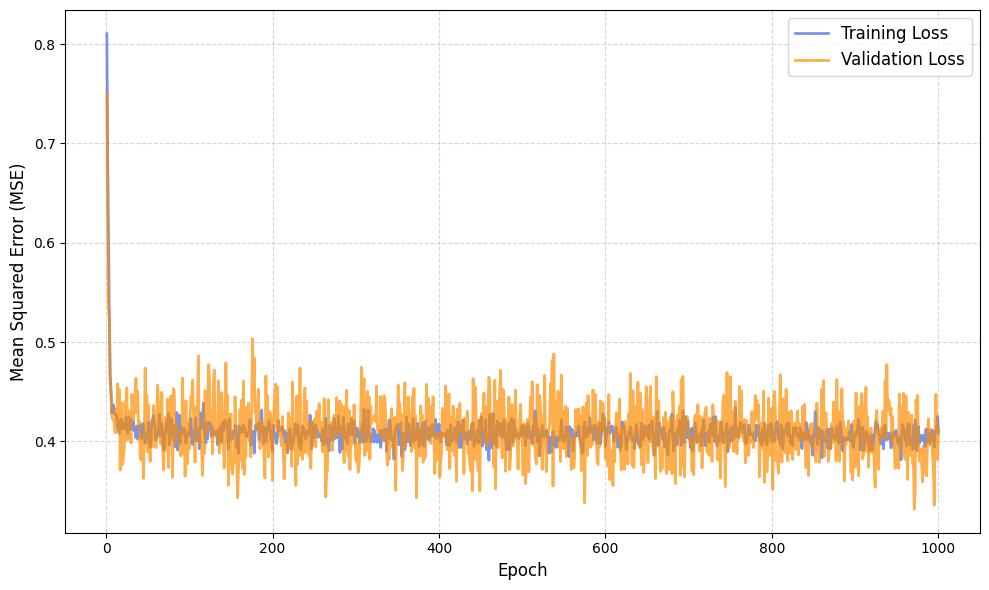

In [ ]:
#Loss plot to visualize the training
plt.figure(figsize=(10, 6))
plt.plot(range(1, N_EPOCHS + 1), train_losses, color='royalblue', linewidth=2, label='Training Loss', alpha = 0.7)
plt.plot(range(1, N_EPOCHS + 1), val_losses, color='darkorange', linewidth=2, label='Validation Loss', alpha = 0.7)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(fontsize=12, loc='upper right')

plt.tight_layout()

plt.show()

# **REVERSE PROCESS**
Starting from a pure gaussian noise $x_t$, we want to predict the amount of noise that was added at the step $t$ and reconstruct $x_0$ starting from the diffusion coefficients.

In [ ]:
def sample_reverse(g, count):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    g : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    Returns
    -------
    x : torch.Tensor
        The final sample from the model
    """
    g.eval()
    with torch.no_grad():
      # --- ALGORITHM 2 (DDPM) ---
      # 1. Start from pure gaussian noise x_T ~ N(0, I)
      x = torch.randn((count, 1))

      history_x = []
      plot_steps = [TIME_STEPS-1, int(TIME_STEPS*0.6), int(TIME_STEPS*0.2), 0] #define 4 main steps in time when to append the evolution into history: last one, 60% , 20% and first step

      trajectories = []

      # 2. Iterate from t=T-1 a t=0
      for i in reversed(range(TIME_STEPS)):
          # Preparing the input (x_t e t_norm) for the network
          t_tensor = torch.full((count, 1), i, dtype=torch.float)
          t_norm = t_tensor / TIME_STEPS
          net_input = torch.cat([x, t_norm], dim=-1)

          # Predict the noise for x at t_norm
          pred_noise = g(net_input)

          # Diffusion coefficients at current step t
          alpha_t = alpha
          alpha_bar_t = alphas_cumprod[i]

          # 3. Add noise z ~ N(0, I) for every step except for the last one, in order to keep the training away from being stuck in one point
          z = torch.randn_like(x) if i > 0 else torch.zeros_like(x)

          # 4. Calculate x_{t-1} removing the predicted noise
          x = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * pred_noise) + torch.sqrt(BETA) * z

          # Saving step
          if i in plot_steps:
              history_x.append((i, x.numpy()))

          trajectories.append(x.numpy())

      return history_x, trajectories


history_x, trajectories = sample_reverse(g, 1000)
samples = history_x[-1][1] #"samples" will be the final denoised sample at t=0

# **PLOT OF THE SAMPLE AT LAST STEP t**

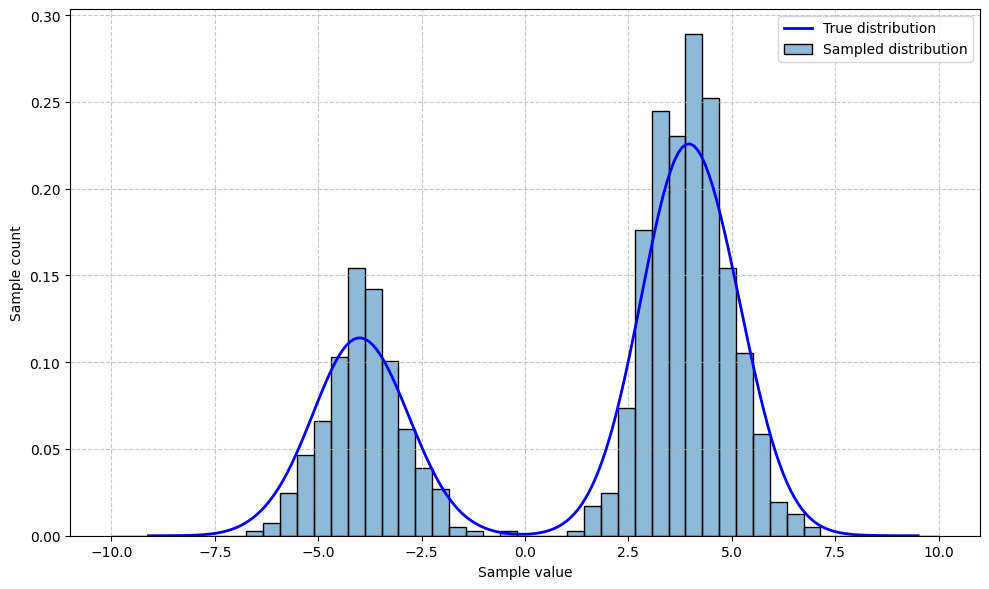

In [ ]:
# plot the denoised samples
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bins = np.linspace(-10, 10, 50)
sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples, ax=ax, bins=bins,  label='Sampled distribution', stat='density')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')
plt.tight_layout()
plt.show()

# **PLOTS FOR INTERMEDIATE STEPS t**

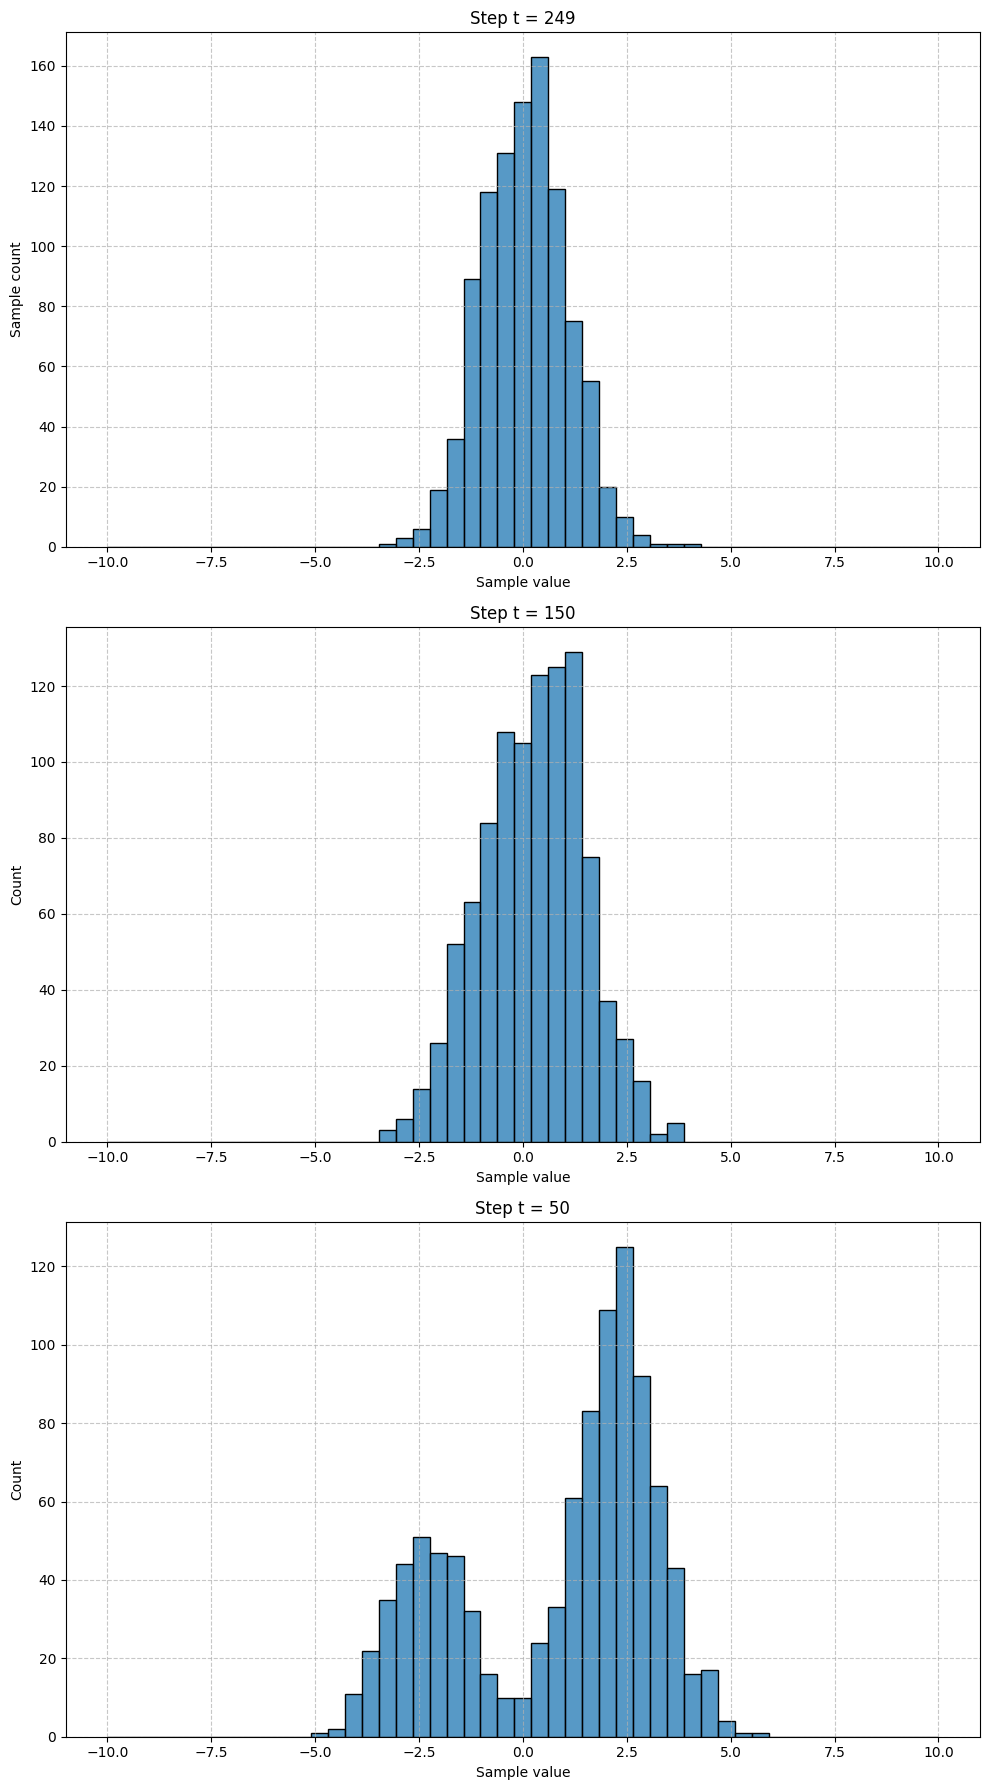

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10,18))
bins = np.linspace(-10, 10, 50)
for idx, (step, sample) in enumerate(history_x[:3]):

    sns.histplot(sample.flatten(), ax=axes[idx], bins=bins)
    axes[idx].set_title(f"Step t = {step}")
    axes[idx].set_xlabel('Sample value')
    axes[idx].grid(True, linestyle='--', alpha=0.7, zorder = 0)
    if idx == 0: # Only set ylabel for the first subplot for cleaner look
        axes[idx].set_ylabel('Sample count')


plt.tight_layout()
plt.show()

# **TRAJECTORY PLOT**

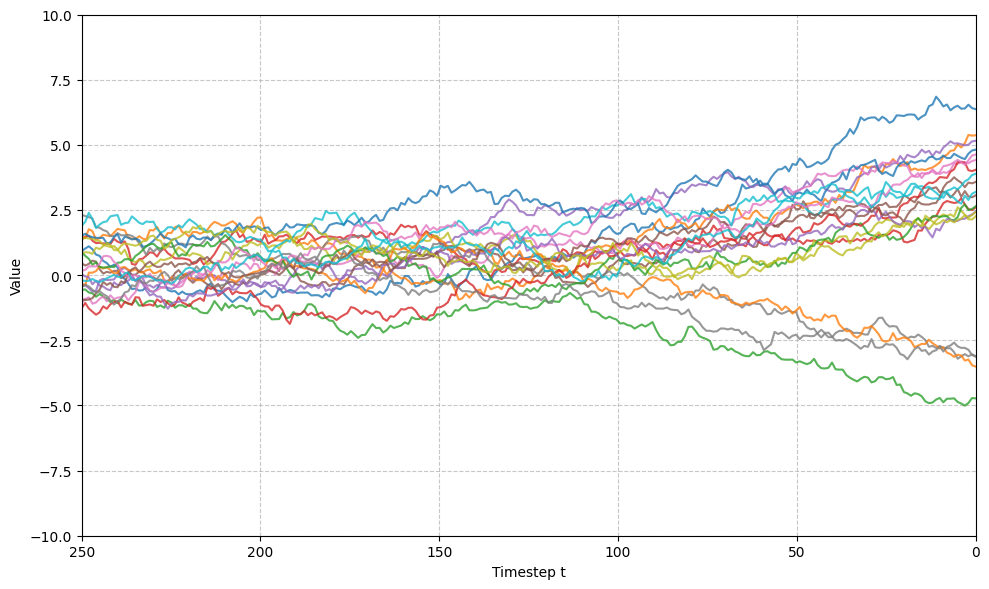

In [ ]:
#Convert to numpy
traj_array = np.array(trajectories).squeeze(-1)

time_axis = np.linspace(TIME_STEPS, 0, traj_array.shape[0])

plt.figure(figsize=(10, 6))

plt.plot(time_axis, traj_array[:, :20], linewidth=1.5, alpha=0.8)

plt.xlim(TIME_STEPS, 0)
plt.ylim(-10, 10)
plt.xlabel("Timestep t")
plt.ylabel("Value")
#plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()